# Lab 8: KNN Classifier for Banknote Authentication

This notebook performs:
1. Exploratory Data Analysis (EDA)
2. Data cleaning and feature scaling
3. Optimal K selection using the elbow method
4. Final KNN model evaluation (confusion matrix + classification report)

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
sns.set_theme(style="whitegrid")

# Load dataset
df = pd.read_csv("data_banknote_authentication.csv")

# Basic cleaning:
# 1) Ensure numeric columns are numeric
# 2) Remove rows with invalid/missing values
# 3) Keep only binary classes 0/1
for col in ["Variance", "Skewness", "Curtosis", "Entropy", "Class"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna().copy()
df = df[df["Class"].isin([0, 1])].copy()
df["Class"] = df["Class"].astype(int)

print("Dataset loaded and cleaned successfully.")

Dataset loaded and cleaned successfully.


Shape of dataset: (1372, 5)

Class distribution:
Class
0    762
1    610
Name: count, dtype: int64


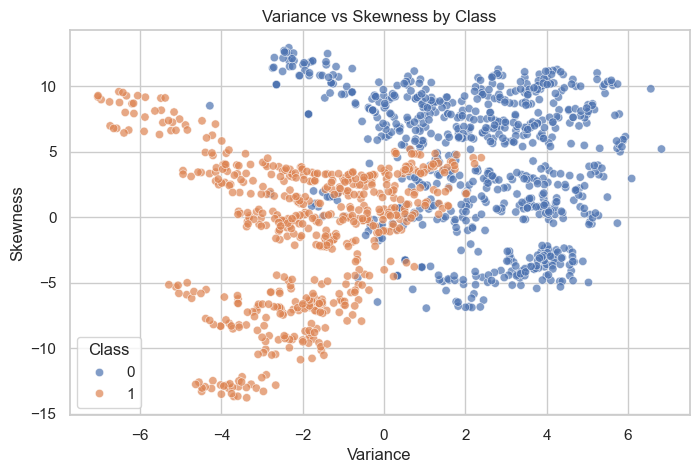

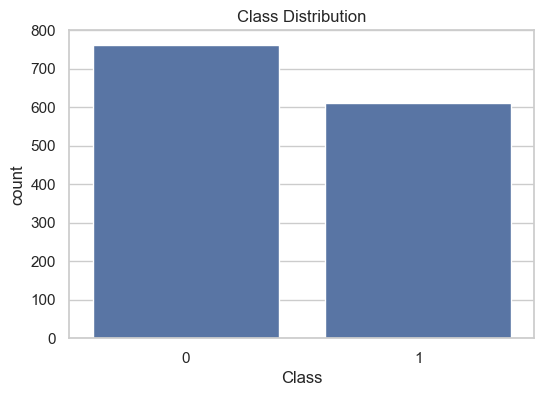

In [11]:
# Task 1: Exploratory Data Analysis (EDA)
print("Shape of dataset:", df.shape)
print("\nClass distribution:")
print(df["Class"].value_counts())

# Visualize relationship between two numerical columns
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Variance", y="Skewness", hue="Class", alpha=0.7)
plt.title("Variance vs Skewness by Class")
plt.show()

# Optional: class distribution plot
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Class")
plt.title("Class Distribution")
plt.show()

In [12]:
# Task 2: Data Transformation (Feature Scaling)
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Task 2 completed: Data cleaned and features scaled.")
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Task 2 completed: Data cleaned and features scaled.
Training set shape: (1097, 4)
Test set shape: (275, 4)


Task 3 completed: Optimal K = 3
Minimum error rate: 0.0000


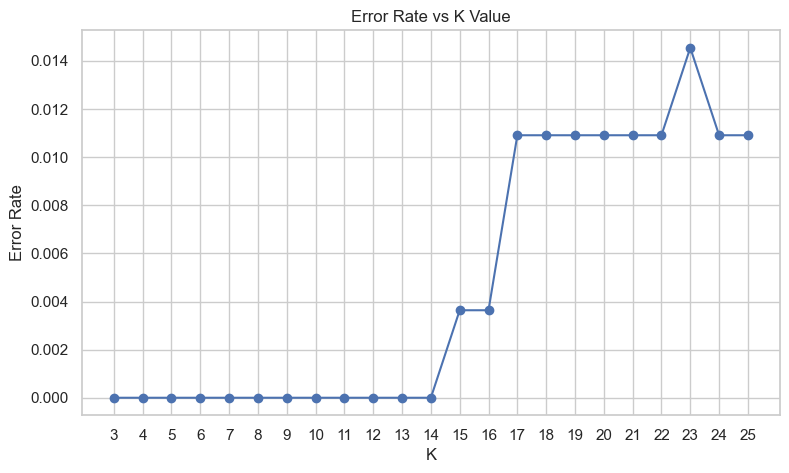

In [13]:
# Task 3: Optimal K selection (Elbow method)
error_rates = []
k_values = list(range(3, 26))

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred_k = knn.predict(X_test_scaled)
    error = np.mean(y_pred_k != y_test)
    error_rates.append(error)

optimal_k = k_values[int(np.argmin(error_rates))]
print(f"Task 3 completed: Optimal K = {optimal_k}")
print(f"Minimum error rate: {min(error_rates):.4f}")

plt.figure(figsize=(9, 5))
plt.plot(k_values, error_rates, marker="o")
plt.title("Error Rate vs K Value")
plt.xlabel("K")
plt.ylabel("Error Rate")
plt.xticks(k_values)
plt.grid(True)
plt.show()

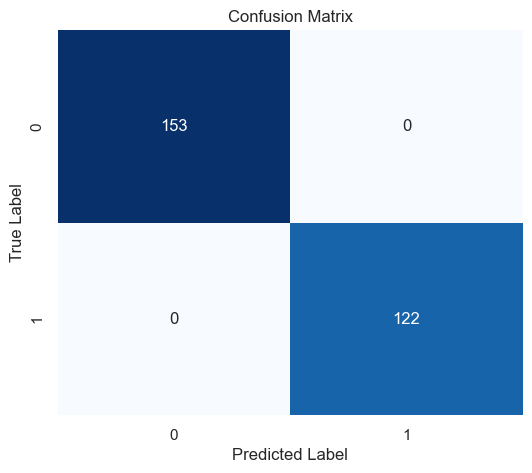

Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       153
           1       1.00      1.00      1.00       122

    accuracy                           1.00       275
   macro avg       1.00      1.00      1.00       275
weighted avg       1.00      1.00      1.00       275



In [14]:
# Task 4: Final KNN model using optimal K
final_knn = KNeighborsClassifier(n_neighbors=optimal_k)
final_knn.fit(X_train_scaled, y_train)

y_pred_final = final_knn.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred_final)
acc = accuracy_score(y_test, y_pred_final)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

print(f"Accuracy: {acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))